<a href="https://colab.research.google.com/github/nathannguyen13/A01-data-wrangling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Nathan Nguyen

**Date:** 9/2/26

In [2]:
!git clone https://github.com/nathannguyen13/A01-data-wrangling

Cloning into 'A01-data-wrangling'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 9 (from 1)
Receiving objects: 100% (12/12), 3.43 MiB | 11.47 MiB/s, done.


In [5]:
# Your Phase 1 solution to the problem goes here.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [22]:
#Q1 - 1

df = pd.read_csv('A01-data-wrangling/data/airbnb_hw.csv', low_memory=False)

df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace(r'[$, ]', '', regex=True)
df['Price'] = df['Price'].pipe(pd.to_numeric, errors='coerce' )

missing_num = df['Price'].isna().sum()

display(df)
print(f"Sum of missing values: {missing_num}")




,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30473,43022976,8/31/2015,10 Mins to Time Square/two floors,Queens,Apartment,NaN,Entire home/apt,11101.0,5.0,1,0,300,NaN
30474,42993382,8/31/2015,"1BR ocean view & F,Q train st",Brooklyn,Apartment,NaN,Private room,11224.0,2.0,1,0,125,NaN
30475,43033067,8/31/2015,Amazing Private Room,Brooklyn,Other,NaN,Private room,11206.0,1.0,1,0,80,NaN
30476,43000991,8/31/2015,Charming private female room: UWS,Manhattan,Apartment,NaN,Private room,10025.0,1.0,1,0,35,NaN


Sum of missing values: 0


I converted the price column into a string so that I could remove the \$ and \, characters, then used to_numeric to convert it into a numeric type. Before cleaning the data, there were 0 missing values, but after removing \$ and \, and without setting regex=True, any numbers greater than 999 failed to convert into a numeric type, creating 181 missing values.

In [7]:
#Q1 - 2
df = pd.read_csv('A01-data-wrangling/data/mn_police_use_of_force.csv', low_memory=False)

total = len(df['subject_injury'])
missing_Nan = df['subject_injury'].isna().sum()
percentage = (missing_Nan / total)*100
df["subject_injury"] = df["subject_injury"].fillna('Missing Data')
compare_sf = pd.crosstab(df['subject_injury'], df['force_type'])
print(compare_sf)

print(f"Percentage of missing data in subject injury: {percentage}")
print(f"Sum of missing value: {missing_Nan}")



display(df)

force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
Missing Data        2          7051               1421        0   
No                  0          1093                131        2   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury                                                      
Missing Data                   27                 74           87   
No                             33                 34            0   
Yes                            44                 40            0   

force_type      Less Lethal Projectile  Maximal Restraint Technique  \
subject_injury                                                        
Missing Data                         0                          170   
No                                   1                            0   
Yes                               

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,Missing Data,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,Missing Data,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,Missing Data,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,Missing Data,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,Missing Data,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12920,2021/08/30 21:38:46,Assault in Progress,Yes,ASLT5,Missing Data,Bodily Force,Joint Lock,White,Female,69.0,NaN,1,Loring Park
12921,2021/08/30 22:32:22,Unwanted Person,Yes,CIC,Missing Data,Bodily Force,Joint Lock,NaN,NaN,NaN,NaN,1,Cedar Riverside
12922,2021/08/31 12:03:08,Overdose w/All,Yes,FORCE,Missing Data,Bodily Force,Body Weight Pin,Black,Male,NaN,NaN,3,Seward
12923,2021/08/31 12:52:52,Attempt Pick-Up,No,WT,Missing Data,Bodily Force,Body Weight Pin,Black,Male,31.0,NaN,4,Camden Industrial


Missingness is not random, rather it varies a lot by force type. Less Lethal and Maximal Restraint Technique are missing 100% of the time, while less severe or more common force types like Bodily Force are missing around 75%. This suggests that injury status is more likely to go unrecorded for certain types of force, rather than missing at random across the board

0.0 2026.0
count    4052.000000
mean       28.182132
std        14.694399
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age, dtype: float64
0.7394969790642124


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22,Type_clean
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,NaN,...,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unprovoked
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43.0,...,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unprovoked
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,NaN,...,Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Provoked
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27.0,...,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Provoked
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71.0,...,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unprovoked
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7112,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,...,"H. Taunton; N. Bartlett, p. 234",ND-0005-RoebuckBay.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0005,ND.0005,6.0,NaN,NaN,Unprovoked
7113,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,...,"H. Taunton; N. Bartlett, pp. 233-234",ND-0004-Ahmun.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0004,ND.0004,5.0,NaN,NaN,Unprovoked
7114,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,...,"F. Schwartz, p.23; C. Creswell, GSAF",ND-0003-Ocracoke_1900-1905.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0003,ND.0003,4.0,NaN,NaN,Unprovoked
7115,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,...,"The Sun, 10/20/1938",ND-0002-JulesPatterson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0002,ND.0002,3.0,NaN,NaN,Unprovoked


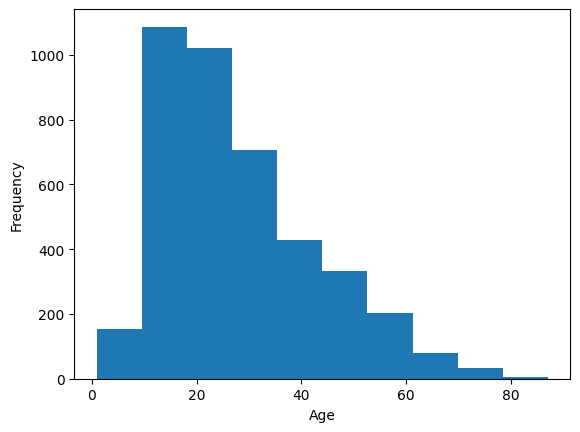

In [30]:
#Q2

df = pd.read_excel('GSAF5.xls')
df = df.dropna(axis=1, how='all')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
print(df['Year'].min(), df['Year'].max())
df['Age'] = pd.to_numeric(df['Age'].astype(str).str.extract(r'(\d+)', expand=False), errors='coerce')

df['Age'].plot(
    kind='hist',
    bins=10,
)
plt.xlabel('Age')
plt.ylabel('Frequency')

def clean_type(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).strip().lower()
    if val == 'unprovoked':
        return 'Unprovoked'
    elif val == 'provoked':
        return 'Provoked'
    else:
        return 'Unknown'

df['Type_clean'] = df['Type'].apply(clean_type)
prop_unprovoked = (df['Type_clean'] == 'Unprovoked').mean()

print(df['Age'].describe())
print(prop_unprovoked)
display(df)


3. Year: I cleaned Year and found values ranging from 0 to 2026. I filtered to attacks since 1940 to focus on more modern records.

4. Age: I cleaned Age by extracting the number from each entry. Valid ages range from 1 to 87, with a median of 24 and most victims between 17 and 37 years old.

6. Type: I cleaned Type so it only takes three values: Unprovoked, Provoked, or Unknown. About 74% of attacks are Unprovoked.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** b82553ccc672b42a53b2fe80c393524f925dfe45


- **AI tool and model used:** Claude Sonnet 5

### *Prompts used

1. How can I further optimize the solutions for Q1?
2. How can I further optimize the solution for Q2?



### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
Q1-1 (Price)

Minor robustness gap: your regex r'[$, ]' only strips $, ,, and regular spaces. If any price strings have other stray characters (non-breaking spaces, stray periods, etc. — this actually showed up in the shark data with '\xa0'), they'd silently fail to convert and get coerced to NaN without you noticing. A slightly more defensive version:

python
df['Price'] = df['Price'].str.replace(r'[^\d.]', '', regex=True)

This says "remove anything that isn't a digit or a decimal point" — a more robust way to isolate the numeric part regardless of what formatting junk surrounds it. (Not strictly necessary if you've already confirmed 0 missing values, but it's a more defensible, general-purpose cleaning choice to mention.)

Style nit (optional): .pipe(pd.to_numeric, errors='coerce') works, but it's just a roundabout way of writing:

python
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

Same result, more direct. .pipe() is more useful when chaining multiple custom functions — for a single built-in function call it doesn't add anything here.

Q1-2 (subject_injury)

The one real improvement worth adding: your crosstab shows raw counts, which is correct and fixed, but it doesn't make the pattern (which force types are worst) easy to see at a glance — you have to eyeball and divide manually, like we did earlier. Adding a normalized version makes the missingness pattern immediately visible, which is literally what the question is asking for:

2. ...
Q2

1. Filter out blank filler rows before everything else

This is the most impactful fix — the raw GSAF spreadsheet has thousands of empty rows that aren't real records. If you don't filter these out first, every proportion downstream (missing %, male %, unprovoked %) gets diluted:

python
df = df[df['Case Number'].notna() | df['Date'].notna()].copy()

Do this right after dropping empty columns, before any other cleaning.

2. Vectorize the Age cleaning (you're already doing this — good)

Your str.extract(r'(\d+)') approach is already vectorized rather than using a slow .apply() with a custom function — that's the right call for performance on a real dataset. One small addition worth noting as a documented limitation rather than fixing: multi-victim entries like "28 & 26" only capture the first number, and "18 months" gets read as age 18. You don't need to fix these, just flag them.

3. Handle the Sex column's trailing space and stray typos
python
sex = df['Sex '].astype(str).str.strip().str.upper()
sex = sex.replace('NAN', np.nan)
sex_clean = sex.where(sex.isin(['M', 'F']))  # anything else becomes NaN

prop_male = (sex_clean == 'M').mean()

.where() here is cleaner than manually filtering — it keeps the Series the same length (useful if you want to merge it back into df) while converting anything that isn't 'M'/'F' to NaN.

4. Use value_counts(normalize=True) instead of manual .mean() calls

For Type_clean, this gives you all three proportions (Unprovoked/Provoked/Unknown) in one line instead of computing each separately:

python
type_props = df['Type_clean'].value_counts(normalize=True)
print(type_props.round(3))

Also useful as a sanity check — the three values should sum to 1.0.

5. Make the histogram trend/decade output cleaner

If you're grouping by decade for the "increasing/decreasing/constant" trend question, this is a more explicit version than raw groupby:

python
recent = df[df['Year'] >= 1940].copy()
recent['Decade'] = (recent['Year'] // 10 * 10).astype(int)
decade_counts = recent.groupby('Decade').size()
print(decade_counts)

.astype(int) avoids printing decade labels as 1940.0 instead of 1940.

6. One edge case worth checking: duplicate/leftover columns

Earlier I noticed columns like Case Number.1, Case Number.2, href formula in the raw file — these are usually leftover artifacts from the spreadsheet's internal hyperlink formatting, not real data. Worth a quick check:

python
print(df.filter(regex=r'\.\d$|href').columns.tolist())

If these show up and are genuinely empty or redundant, drop them explicitly even if dropna(how='all') didn't catch them (since they may have a few non-null junk values, like the "stopped here" note-to-self I found buried in one row of my mirror copy).

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [33]:
# Your Phase 2 solution to the problem goes here.
#Q1 - 1

df = pd.read_csv('A01-data-wrangling/data/airbnb_hw.csv', low_memory=False)

df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace(r'[^\d.]', '', regex=True)  #keep only digits and decimal points
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

missing_num = df['Price'].isna().sum()

display(df)
print(f"Sum of missing values: {missing_num}")


,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30473,43022976,8/31/2015,10 Mins to Time Square/two floors,Queens,Apartment,NaN,Entire home/apt,11101.0,5.0,1,0,300,NaN
30474,42993382,8/31/2015,"1BR ocean view & F,Q train st",Brooklyn,Apartment,NaN,Private room,11224.0,2.0,1,0,125,NaN
30475,43033067,8/31/2015,Amazing Private Room,Brooklyn,Other,NaN,Private room,11206.0,1.0,1,0,80,NaN
30476,43000991,8/31/2015,Charming private female room: UWS,Manhattan,Apartment,NaN,Private room,10025.0,1.0,1,0,35,NaN


Sum of missing values: 0


In [36]:
#Q1 - 2

df = pd.read_csv('A01-data-wrangling/data/mn_police_use_of_force.csv', low_memory=False)

total = len(df['subject_injury'])
missing_Nan = df['subject_injury'].isna().sum()
percentage = (missing_Nan / total) * 100

df["subject_injury"] = df["subject_injury"].fillna('Missing Data')

#raw counts
compare_sf = pd.crosstab(df['subject_injury'], df['force_type'])
print(compare_sf)
print()

#% missing within each force_type, makes the pattern visible directly
compare_sf_pct = pd.crosstab(df['subject_injury'], df['force_type'], normalize='columns') * 100
print(compare_sf_pct.round(1))
print()

print(f"Percentage of missing data in subject injury: {percentage:.1f}%")
print(f"Sum of missing value: {missing_Nan}")

display(df)

force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
Missing Data        2          7051               1421        0   
No                  0          1093                131        2   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury                                                      
Missing Data                   27                 74           87   
No                             33                 34            0   
Yes                            44                 40            0   

force_type      Less Lethal Projectile  Maximal Restraint Technique  \
subject_injury                                                        
Missing Data                         0                          170   
No                                   1                            0   
Yes                               

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,Missing Data,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,Missing Data,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,Missing Data,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,Missing Data,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,Missing Data,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12920,2021/08/30 21:38:46,Assault in Progress,Yes,ASLT5,Missing Data,Bodily Force,Joint Lock,White,Female,69.0,NaN,1,Loring Park
12921,2021/08/30 22:32:22,Unwanted Person,Yes,CIC,Missing Data,Bodily Force,Joint Lock,NaN,NaN,NaN,NaN,1,Cedar Riverside
12922,2021/08/31 12:03:08,Overdose w/All,Yes,FORCE,Missing Data,Bodily Force,Body Weight Pin,Black,Male,NaN,NaN,3,Seward
12923,2021/08/31 12:52:52,Attempt Pick-Up,No,WT,Missing Data,Bodily Force,Body Weight Pin,Black,Male,31.0,NaN,4,Camden Industrial


Q1 AI-Assisted Revision

Main improvements: Fixed the Price column not being cleaned (missing regex=True), fixed a wrong missing-value percentage (.count() vs len()), and fixed the crosstab hiding missing data because it was built before fillna().

AI mistakes/limitations: The crosstab ordering bug wasn't caught until a another check up, not on the first pass.

Verification: Confirmed each fix by re-running the code, checked Price had 0 missing values, compared .count() vs len() output, and confirmed the two hidden force types now showed up as 100% missing.

Remaining concerns: Missing subject_injury values are grouped as one category, but not unclear why some force types have no injury data.

Year range: 0.0 to 2026.0

Attacks by decade since 1940:
Decade
1940     283
1950     467
1960     618
1970     339
1980     438
1990     572
2000    1022
2010    1249
2020     593
dtype: int64

Age summary:
count    4052.000000
mean       28.182132
std        14.694399
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age, dtype: float64


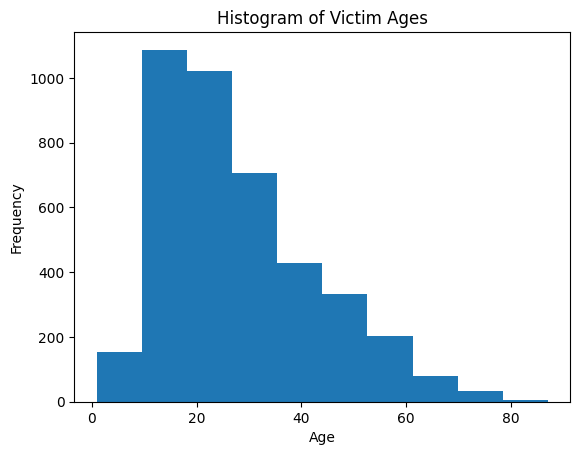


Using column: 'Sex'
Proportion male: 80.3%

Type breakdown:
Type_clean
Unprovoked    0.739
Unknown       0.169
Provoked      0.091
Name: proportion, dtype: float64

Proportion unprovoked: 73.9%


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22,Type_clean
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,NaN,...,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unprovoked
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43.0,...,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unprovoked
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,NaN,...,Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Provoked
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27.0,...,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Provoked
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71.0,...,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unprovoked
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7112,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,...,"H. Taunton; N. Bartlett, p. 234",ND-0005-RoebuckBay.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0005,ND.0005,6.0,NaN,NaN,Unprovoked
7113,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,...,"H. Taunton; N. Bartlett, pp. 233-234",ND-0004-Ahmun.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0004,ND.0004,5.0,NaN,NaN,Unprovoked
7114,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,...,"F. Schwartz, p.23; C. Creswell, GSAF",ND-0003-Ocracoke_1900-1905.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0003,ND.0003,4.0,NaN,NaN,Unprovoked
7115,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,...,"The Sun, 10/20/1938",ND-0002-JulesPatterson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0002,ND.0002,3.0,NaN,NaN,Unprovoked


In [35]:
#Q2

df = pd.read_excel('GSAF5.xls')

df = df.dropna(axis=1, how='all')

df = df[df['Case Number'].notna() | df['Date'].notna()].copy()

df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
print(f"Year range: {df['Year'].min()} to {df['Year'].max()}")

recent = df[df['Year'] >= 1940].copy()
recent['Decade'] = (recent['Year'] // 10 * 10).astype(int)
decade_counts = recent.groupby('Decade').size()
print("\nAttacks by decade since 1940:")
print(decade_counts)

df['Age'] = pd.to_numeric(df['Age'].astype(str).str.extract(r'(\d+)', expand=False), errors='coerce')
print("\nAge summary:")
print(df['Age'].describe())

df['Age'].plot(kind='hist', bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Victim Ages')
plt.show()

sex_col = [c for c in df.columns if 'sex' in c.lower()][0]
print(f"\nUsing column: '{sex_col}'")

sex = df[sex_col].astype(str).str.strip().str.upper()
sex = sex.replace('NAN', np.nan)
sex_clean = sex.where(sex.isin(['M', 'F']))

prop_male = (sex_clean == 'M').mean()
print(f"Proportion male: {prop_male:.1%}")

def clean_type(val):
    if pd.isna(val):
        return 'Unknown'
    val = str(val).strip().lower()
    if val == 'unprovoked':
        return 'Unprovoked'
    elif val == 'provoked':
        return 'Provoked'
    else:
        return 'Unknown'

df['Type_clean'] = df['Type'].apply(clean_type)

type_props = df['Type_clean'].value_counts(normalize=True)
print("\nType breakdown:")
print(type_props.round(3))

prop_unprovoked = (df['Type_clean'] == 'Unprovoked').mean()
print(f"\nProportion unprovoked: {prop_unprovoked:.1%}")

display(df)

Q2 AI-Assisted Revision

Main improvements: Removed thousands of blank filler rows before calculating percentages, and fixed a KeyError from a hardcoded column name.

AI mistakes/limitations: The AI couldn't access the live file directly, so early example numbers came from an older file and didn't match the real data.

Verification: Ran the code on the actual downloaded file and checked the output made sense before/after fixes.

Remaining concerns: The Age cleaning can misread things like "18 months" or entries listing multiple ages.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

I thoroughly looked through class notes and did research on google for all Pandas dataframe, but I wasn't sure if all my solutions were fully correct or optimal. So what I did was I  ask Claude to optimize the answer for Q1 and Q2 and then I made the correct edits to my solutions. For Q1, the AI fixed a bug where the Price column wasn't actually being cleaned because a setting (regex=True) was missing, so the $ and commas never got removed. It also fixed a wrong missing-value percentage calculation, and realized that the crosstab was built before the missing values were filled in, which hid some important results. For Q2, the main fix was removing thousands of blank rows in the raw file before calculating percentages, since leaving them in threw off the numbers. It also fixed an error caused by a mismatched column name, and cleaned up a few small formatting issues.Though to make sure that the new code works, I made sure to run everything and compare the results from phase 2 with phase 1, ensuring that everything matches up. Though I believe Claude was able to come up with the most optimal solution for each questions better than me, I am still not 100% sure if everything is flawless since I am using Sonnet 5 rather than a stronger model.